# Complete Supervised Regression Project — House Price Prediction

This notebook walks through the project in learning order: data understanding, EDA, simple/polynomial regression, preprocessing, multiple models, evaluation, and interpretation.

> Dataset note: the bundled housing data is synthetic and reproducible. It is designed to demonstrate regression workflows, not to represent a real housing market.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from config import RAW_DATA, TARGET, RANDOM_STATE

df = pd.read_csv(RAW_DATA)
df.head()


,Area_sqft,Bedrooms,Bathrooms,Floors,HouseAge_years,DistanceToCity_km,SchoolRating,CrimeRate,ParkingSpaces,LotSize_sqft,PropertyType,LocationQuality,Furnishing,HasGarage,HasGarden,Price_USD
0,1942.5,4,4,3,3.4,16.75,7.45,4.72,3,2752.6,Independent House,Average,Semi-Furnished,0,0,596288.41
1,1075.8,2,1,3,7.8,1.02,6.86,2.53,0,2495.0,Townhouse,Poor,Semi-Furnished,1,1,316053.59
2,4195.3,7,4,3,22.1,8.75,3.99,2.96,4,5891.7,Independent House,Good,Unfurnished,1,1,1310476.81
3,4017.1,6,4,1,20.9,11.57,6.78,2.06,3,7686.7,Independent House,Average,Furnished,1,0,1152050.78
4,566.3,1,1,14,22.9,9.89,5.25,0.40,0,346.9,Apartment,Poor,Unfurnished,1,0,70000.00


## 1. Data understanding


In [3]:
print("Shape:", df.shape)
display(df.info())
display(df.describe(include="all").T)
print("Missing values:")
display(df.isna().sum().sort_values(ascending=False))


Shape: (6000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area_sqft          6000 non-null   float64
 1   Bedrooms           6000 non-null   int64  
 2   Bathrooms          6000 non-null   int64  
 3   Floors             6000 non-null   int64  
 4   HouseAge_years     5893 non-null   float64
 5   DistanceToCity_km  6000 non-null   float64
 6   SchoolRating       5868 non-null   float64
 7   CrimeRate          5904 non-null   float64
 8   ParkingSpaces      6000 non-null   int64  
 9   LotSize_sqft       5928 non-null   float64
 10  PropertyType       6000 non-null   object 
 11  LocationQuality    6000 non-null   object 
 12  Furnishing         5940 non-null   object 
 13  HasGarage          6000 non-null   int64  
 14  HasGarden          6000 non-null   int64  
 15  Price_USD          6000 non-null   float64
dtypes: flo

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area_sqft,6000.0,NaN,NaN,NaN,1811.0492,846.838121,450.0,1201.05,1629.8,2242.175,6500.0
Bedrooms,6000.0,NaN,NaN,NaN,2.997333,1.427819,1.0,2.0,3.0,4.0,7.0
Bathrooms,6000.0,NaN,NaN,NaN,2.384,1.052487,1.0,2.0,2.0,3.0,5.0
Floors,6000.0,NaN,NaN,NaN,4.5705,4.136973,1.0,2.0,3.0,7.0,15.0
HouseAge_years,5893.0,NaN,NaN,NaN,16.589411,10.446089,0.1,8.9,14.3,22.1,60.0
DistanceToCity_km,6000.0,NaN,NaN,NaN,10.300457,7.286647,0.3,4.88,8.635,13.95,45.0
SchoolRating,5868.0,NaN,NaN,NaN,6.706679,1.443211,2.0,5.74,6.69,7.69,10.0
CrimeRate,5904.0,NaN,NaN,NaN,2.860899,1.601111,0.04,1.65,2.62,3.88,8.64
ParkingSpaces,6000.0,NaN,NaN,NaN,1.321,0.985793,0.0,1.0,1.0,2.0,4.0
LotSize_sqft,5928.0,NaN,NaN,NaN,2455.247841,2140.5627,150.0,654.5,1941.6,3700.925,14000.0


Missing values:


SchoolRating         132
HouseAge_years       107
CrimeRate             96
LotSize_sqft          72
Furnishing            60
Bathrooms              0
Floors                 0
Area_sqft              0
DistanceToCity_km      0
Bedrooms               0
PropertyType           0
ParkingSpaces          0
LocationQuality        0
HasGarage              0
HasGarden              0
Price_USD              0
dtype: int64

## 2. Exploratory data analysis


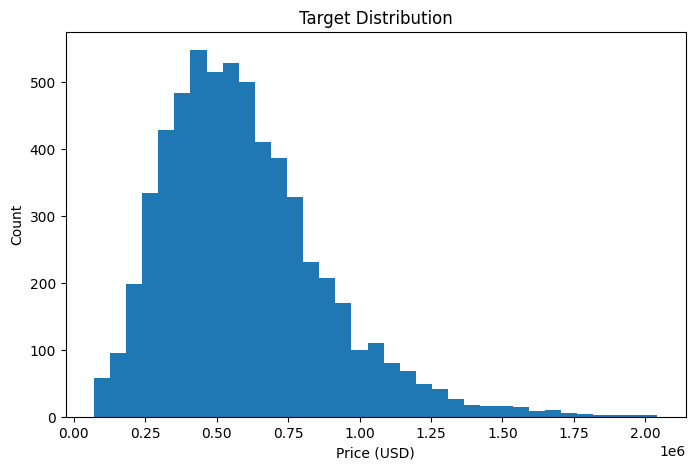

In [4]:
numeric = df.select_dtypes(include=np.number)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[TARGET], bins=35)
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Count")
ax.set_title("Target Distribution")
plt.show()


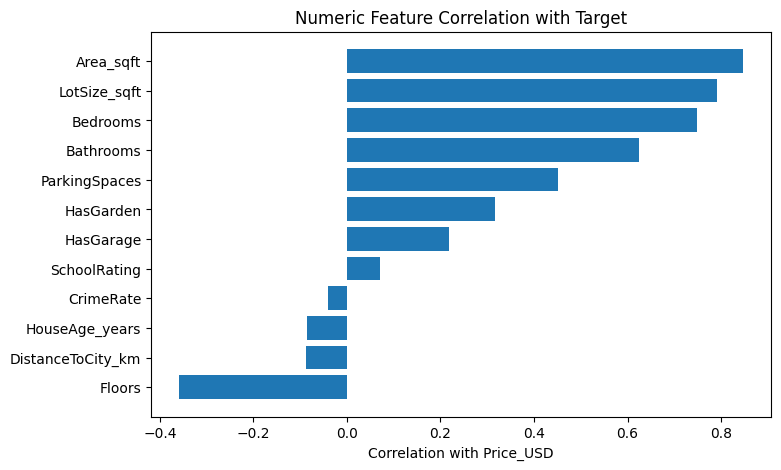

In [5]:
corr = numeric.corr()[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(corr.index, corr.values)
ax.set_xlabel("Correlation with Price_USD")
ax.set_title("Numeric Feature Correlation with Target")
plt.show()


## 3. Simple Linear Regression

Use exactly one predictor (`Area_sqft`) so the model is easy to visualize and explain.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[["Area_sqft"]]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

simple_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LinearRegression())
])
simple_model.fit(X_train, y_train)
simple_pred = simple_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, simple_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, simple_pred)))
print("R2:", r2_score(y_test, simple_pred))


MAE: 124070.17220811799
RMSE: 154545.30081539974
R2: 0.7000709132951022


## 4. Polynomial Regression

Compare polynomial degrees 2, 3 and 4 on the same one-dimensional feature.


In [7]:
from sklearn.preprocessing import PolynomialFeatures

poly_rows = []
for degree in [2, 3, 4]:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("model", LinearRegression())
    ])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    poly_rows.append({
        "degree": degree,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })
pd.DataFrame(poly_rows)


,degree,MAE,RMSE,R2
0,2,123832.141889,154186.676829,0.701461
1,3,123832.936804,154188.983542,0.701452
2,4,124473.176171,155053.979338,0.698093


## 5. Full preprocessing pipeline

Numeric columns use median imputation (and scaling when needed). Categorical columns use most-frequent imputation and one-hot encoding.


In [8]:
from data_preprocessing import build_preprocessor, split_features_target

X_all, y_all = split_features_target(df)
preprocessor = build_preprocessor(scale_numeric=True)
Xt = preprocessor.fit_transform(X_all.head(200))
print("Original columns:", X_all.shape[1])
print("Transformed columns:", Xt.shape[1])
print(preprocessor.get_feature_names_out())


Original columns: 15
Transformed columns: 23
['Area_sqft' 'Bedrooms' 'Bathrooms' 'Floors' 'HouseAge_years'
 'DistanceToCity_km' 'SchoolRating' 'CrimeRate' 'ParkingSpaces'
 'LotSize_sqft' 'HasGarage' 'HasGarden' 'PropertyType_Apartment'
 'PropertyType_Independent House' 'PropertyType_Townhouse'
 'PropertyType_Villa' 'LocationQuality_Average' 'LocationQuality_Good'
 'LocationQuality_Poor' 'LocationQuality_Premium' 'Furnishing_Furnished'
 'Furnishing_Semi-Furnished' 'Furnishing_Unfurnished']


## 6. Compare the main regression algorithms


In [9]:
from train_models import train_all_models

# This trains the complete model collection and writes results to reports/.
# Set run_cv=True if you want 5-fold CV for every model (slower).
results, best_model = train_all_models(run_cv=False)
results


Training: Dummy Baseline
Training: Multiple Linear Regression
Training: Ridge Regression
Training: Lasso Regression
Training: ElasticNet Regression
Training: KNN Regressor
Training: Support Vector Regression
Training: Decision Tree Regressor
Training: Random Forest Regressor
Training: Extra Trees Regressor
Training: AdaBoost Regressor
Training: Gradient Boosting Regressor
Training: HistGradientBoosting Regressor
Training: XGBoost Regressor
Training: CatBoost Regressor

Top models:
                         Model          MAE         RMSE       R2  MAPE_percent
    Multiple Linear Regression 34525.083377 44395.257960 0.975250      7.276077
              Ridge Regression 34515.750133 44396.118764 0.975249      7.274657
              Lasso Regression 34510.586384 44448.930571 0.975190      7.275610
            CatBoost Regressor 35992.375691 46772.184944 0.972529      7.711381
             XGBoost Regressor 37498.267510 48018.071165 0.971045      7.934340
HistGradientBoosting Regressor 381

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE_percent
0,Multiple Linear Regression,34525.083377,1.970939e+09,44395.257960,0.975250,0.974766,7.276077
1,Ridge Regression,34515.750133,1.971015e+09,44396.118764,0.975249,0.974765,7.274657
2,Lasso Regression,34510.586384,1.975707e+09,44448.930571,0.975190,0.974705,7.275610
3,CatBoost Regressor,35992.375691,2.187637e+09,46772.184944,0.972529,0.971991,7.711381
4,XGBoost Regressor,37498.267510,2.305735e+09,48018.071165,0.971045,0.970479,7.934340
5,HistGradientBoosting Regressor,38120.522921,2.424647e+09,49240.708051,0.969552,0.968957,8.049445
6,Gradient Boosting Regressor,41389.846613,2.835539e+09,53249.776422,0.964392,0.963696,9.030177
7,Extra Trees Regressor,45609.214422,3.366360e+09,58020.340139,0.957727,0.956900,9.934233
8,Random Forest Regressor,47448.930562,3.714804e+09,60949.192071,0.953351,0.952439,10.130505
9,Decision Tree Regressor,62891.115921,6.590496e+09,81181.872084,0.917239,0.915620,12.746486


## 7. Model comparison


,Model,MAE,RMSE,R2,Adjusted_R2,MAPE_percent
0,Multiple Linear Regression,34525.083377,44395.257960,0.975250,0.974766,7.276077
1,Ridge Regression,34515.750133,44396.118764,0.975249,0.974765,7.274657
2,Lasso Regression,34510.586384,44448.930571,0.975190,0.974705,7.275610
3,CatBoost Regressor,35992.375691,46772.184944,0.972529,0.971991,7.711381
4,XGBoost Regressor,37498.267510,48018.071165,0.971045,0.970479,7.934340
5,HistGradientBoosting Regressor,38120.522921,49240.708051,0.969552,0.968957,8.049445
6,Gradient Boosting Regressor,41389.846613,53249.776422,0.964392,0.963696,9.030177
7,Extra Trees Regressor,45609.214422,58020.340139,0.957727,0.956900,9.934233
8,Random Forest Regressor,47448.930562,60949.192071,0.953351,0.952439,10.130505
9,Decision Tree Regressor,62891.115921,81181.872084,0.917239,0.915620,12.746486


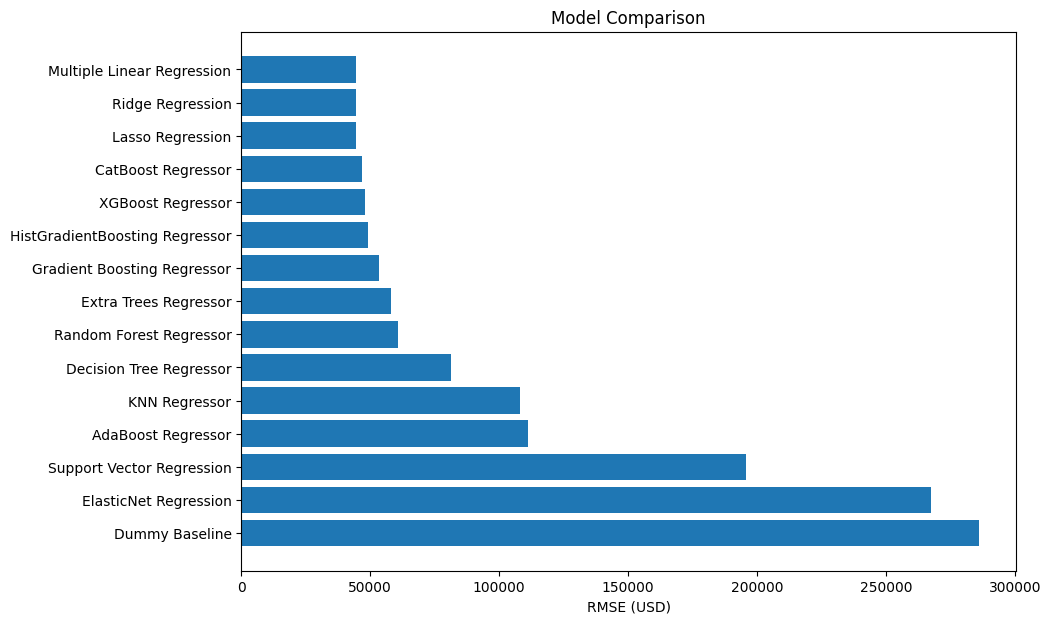

In [10]:
display(results[["Model", "MAE", "RMSE", "R2", "Adjusted_R2", "MAPE_percent"]])

fig, ax = plt.subplots(figsize=(10, 7))
view = results.sort_values("RMSE", ascending=True)
ax.barh(view["Model"], view["RMSE"])
ax.invert_yaxis()
ax.set_xlabel("RMSE (USD)")
ax.set_title("Model Comparison")
plt.show()


## 8. Hyperparameter tuning

The project includes `src/tune_models.py`. Run either:

```bash
python src/tune_models.py --model random_forest
python src/tune_models.py --model gradient_boosting
```

RandomizedSearchCV is used rather than an enormous exhaustive grid.


## 9. Feature importance

Run `python src/explain_model.py` after training. It calculates permutation importance on the original input columns, making the explanation easier for interviews.


## 10. Deployment

After training, launch the app:

```bash
streamlit run app/app.py
```

The application loads `models/best_model.joblib` and uses the same fitted preprocessing pipeline, so prediction-time transformations match training-time transformations.
